# 2. Exploratory Data Analysis

El análisis exploratorio se realiza **únicamente sobre `train.csv`**. Su propósito es comprender los datos y justificar decisiones posteriores, no modificar todavía las variables.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd "/content/drive/MyDrive/AI/Clase 6"

/content/drive/MyDrive/AI/Clase 6


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"
for directory in (DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [5]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
target = contract["target"]
X_train = train_df.drop(columns=target)
y_train = train_df[target]
print(train_df.shape)
train_df.head()

(455, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399,1
1,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075,0
2,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164,1
3,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177,1
4,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994,1


## Distribución de la variable objetivo

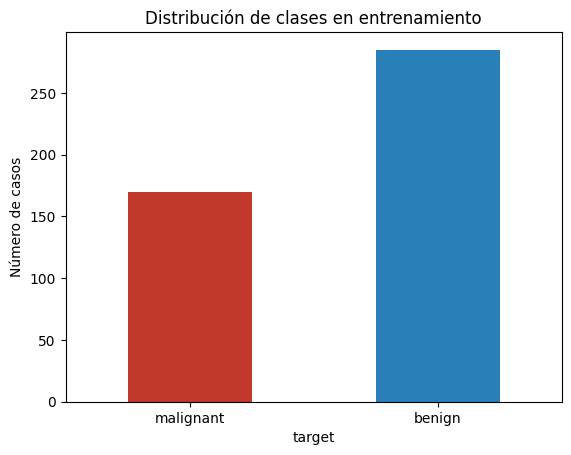

In [6]:
counts = y_train.value_counts().sort_index()
ax = counts.plot.bar(color=["#c0392b", "#2980b9"])
ax.set_xticklabels(contract["target_names"], rotation=0)
ax.set_ylabel("Número de casos")
ax.set_title("Distribución de clases en entrenamiento")
plt.show()

## Distribuciones y escala de las variables

In [7]:
X_train.describe().T[["mean", "std", "min", "50%", "max"]].sort_values("std", ascending=False).head(10)

,mean,std,min,50%,max
worst area,869.026593,552.926912,185.200,683.400,3432.00
mean area,648.541099,344.944564,143.500,541.800,2499.00
area error,39.243747,41.763197,6.802,24.250,525.60
worst perimeter,106.625297,33.195053,50.410,97.590,229.30
mean perimeter,91.557407,24.149231,43.790,85.980,188.50
worst texture,25.647297,6.225470,12.020,25.400,49.54
worst radius,16.177226,4.770020,7.930,14.910,33.13
mean texture,19.247363,4.405291,9.710,18.820,39.28
mean radius,14.067213,3.499380,6.981,13.270,28.11
perimeter error,2.822550,1.973475,0.757,2.235,21.98


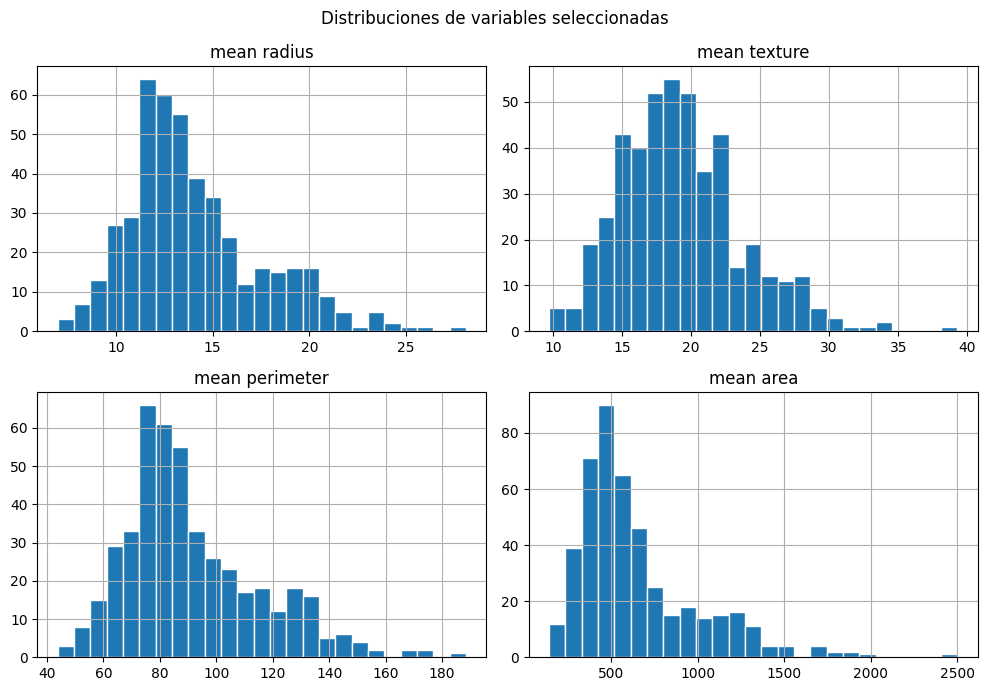

In [8]:
selected = ["mean radius", "mean texture", "mean perimeter", "mean area"]
train_df[selected].hist(figsize=(10, 7), bins=25, edgecolor="white")
plt.suptitle("Distribuciones de variables seleccionadas")
plt.tight_layout()
plt.show()

## Relación con la clase

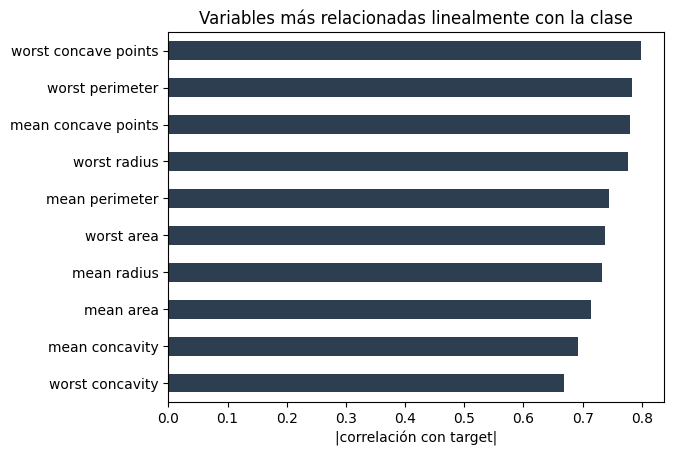

In [9]:
correlations = train_df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
correlations.head(10).sort_values().plot.barh(color="#2c3e50")
plt.xlabel("|correlación con target|")
plt.title("Variables más relacionadas linealmente con la clase")
plt.show()

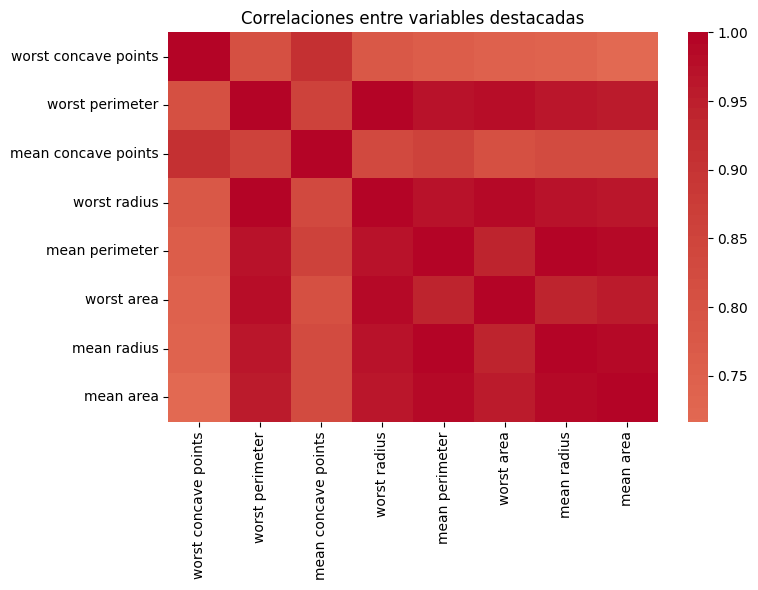

In [10]:
top_features = correlations.head(8).index
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[top_features].corr(), cmap="coolwarm", center=0)
plt.title("Correlaciones entre variables destacadas")
plt.tight_layout()
plt.show()

## Decisiones derivadas del EDA

- Las variables tienen escalas muy diferentes: regresión logística y KNN necesitan estandarización.
- Hay variables fuertemente correlacionadas. Esto no impide entrenar los modelos propuestos, pero debe considerarse al interpretar coeficientes e importancias.
- La clase presenta desbalance moderado; se utilizarán particiones estratificadas.
- No se observan valores faltantes, pero el pipeline incluirá imputación para soportar datos futuros incompletos.